Now that I have selected the templates I will find the thresholds.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from calibration_calcs import (
    compute_auc,
    compute_roc_curve,
    dtw_cross_costs,
    find_threshold_youden_from_roc,
    plot_dtw_scatter,
    plot_roc_curve,
    save_threshold_new,
)
from feature import (
    load_features_from_json, 
    make_mfcc_extractor, 
    plot_mfcc_grid
)

#Path to get templates
DATA_29 = Path(r"C:\Users\HP\Desktop\Skripsie data\29")
RESULTS_29 = DATA_29 / "template_selections"

#Path to get calib_templates
DATA_26 = Path(r"C:\Users\HP\Desktop\Skripsie data\26")
RESULTS_26 = DATA_26 / "template_selections"

#Path to store thresholds
RESULTS = Path(r"C:\Users\HP\Desktop\Skripsie data\Results")
THRESHOLDS = RESULTS / "Thresholds"

#Number of templates
file_name = "10_Templates"
n_temps = 10
n_calib = 10

#Type of feature extraction method
extractor = make_mfcc_extractor()    

[single_tone] Threshold: 8.9659 (J = 0.9800)


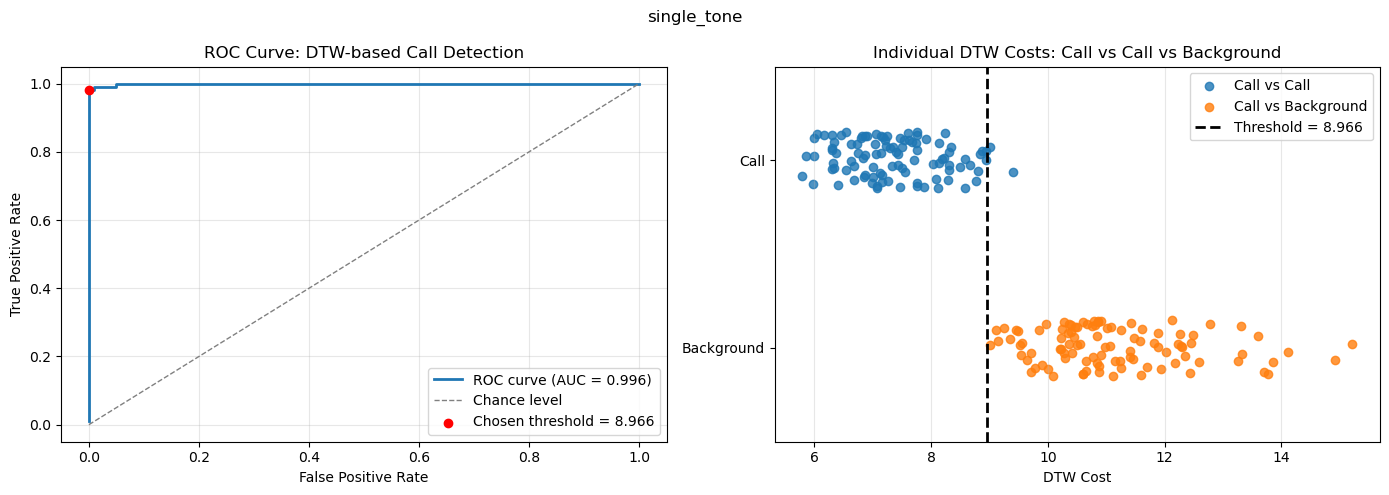

Saved threshold for 'single_tone' [mfcc] to 10_Templates_mfcc_single_tone_threshold.json: threshold=8.9659, J=0.9800, AUC=0.9961
[multi_tone] Threshold: 9.1106 (J = 0.7700)


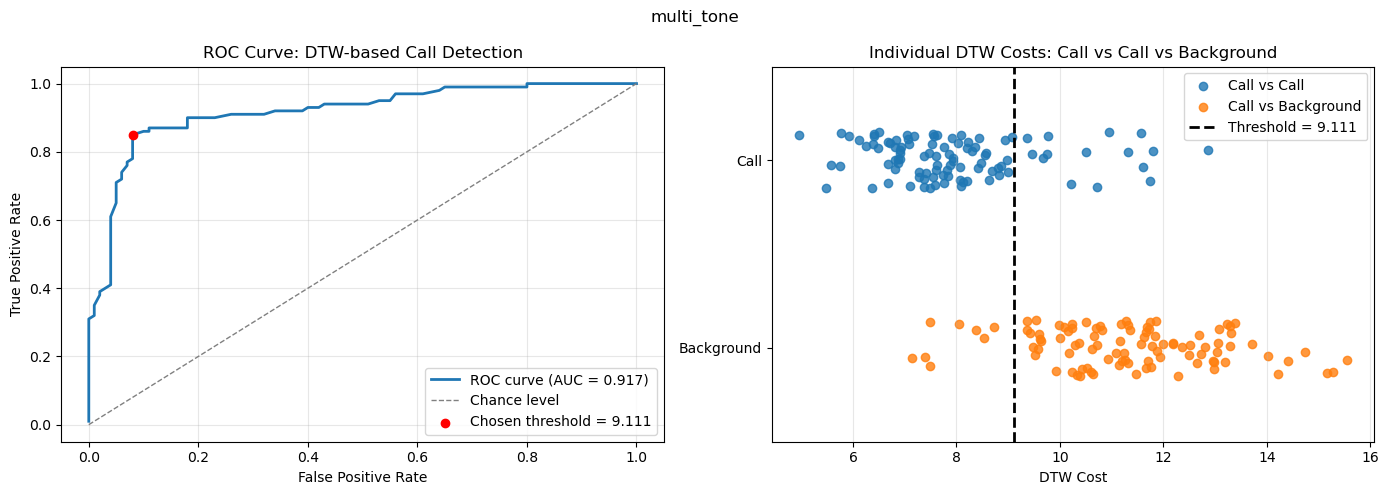

Saved threshold for 'multi_tone' [mfcc] to 10_Templates_mfcc_multi_tone_threshold.json: threshold=9.1106, J=0.7700, AUC=0.9170
[burst_tonal] Threshold: 9.9056 (J = 0.6200)


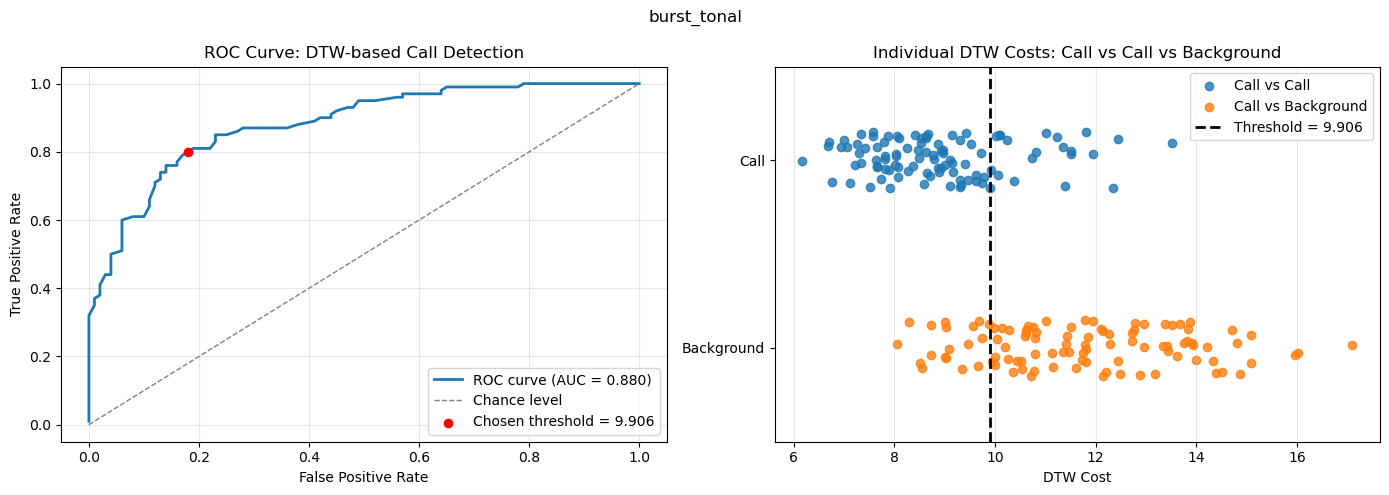

Saved threshold for 'burst_tonal' [mfcc] to 10_Templates_mfcc_burst_tonal_threshold.json: threshold=9.9056, J=0.6200, AUC=0.8803


In [2]:
''' Calculate thresholds and ROC curve for each call type and save the values in seperated . json files
    Plot results
'''


#start of filename where templates are stored
TEMPLATE_filename_start = "20230429_Templates_20230429_102841"

#Create item() for call type file_names
#"call_type" : "calib_file"
CALIB_FILES = {
    "single_tone": "ST_CALIB_26_20230426_075505_single_tone_templates.json",
    "multi_tone":  "MT_CALIB_26_20230426_075505_multi_tone_templates.json",
    "burst_tonal": "BT_CALIB_26_20230426_075505_burst_tonal_templates.json",
}

bg_file = "Bground_CALIB_26_20230426_075505_background.json"

#Load in background templates 
bg_features = load_features_from_json(RESULTS_26 / bg_file, extractor, n_calib)

calib_features_by_type = {}

#loop through each of three call types

for call_type, calib_file in CALIB_FILES.items():
    #Load template featues for specific call type
    template_features = load_features_from_json(RESULTS_29 / f"{TEMPLATE_filename_start}_{call_type}_templates.json", extractor, n_temps)

    #Load calibration features for specific call type
    calib_features = load_features_from_json(RESULTS_26 / calib_file, extractor, n_calib)

    calib_features_by_type[call_type] = calib_features

    #calculate specific call type costs temps against specific call type calib
    call_costs = dtw_cross_costs(template_features, calib_features, extractor.metric)
    #calculate specific call type costs temps against background
    bg_costs = dtw_cross_costs(template_features, bg_features, extractor.metric)

    #compute ROC curve values
    fpr, tpr, thresholds = compute_roc_curve(call_costs, bg_costs)

    #compute best youden threshold
    threshold, j_stat = find_threshold_youden_from_roc(fpr, tpr, thresholds)
    #compute area under curve
    auc = compute_auc(fpr, tpr)
    print(f"[{call_type}] Threshold: {threshold:.4f} (J = {j_stat:.4f})")

    #plot ROC curve and scatter plot of costs for specific call type

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_roc_curve(call_costs, bg_costs, best_threshold=threshold, ax=axes[0])
    plot_dtw_scatter(call_costs, bg_costs, threshold=threshold, ax=axes[1])
    fig.suptitle(f"{call_type}")
    plt.tight_layout()
    plt.show()

    #save specific call type threshold in .json file
    save_threshold_new(threshold, j_stat, auc, call_type=call_type,
                   file_label=file_name, results_dir=THRESHOLDS,
                   n_templates=n_temps, n_background=n_calib,
                   feature_name=extractor.name, feature_params=extractor.params)

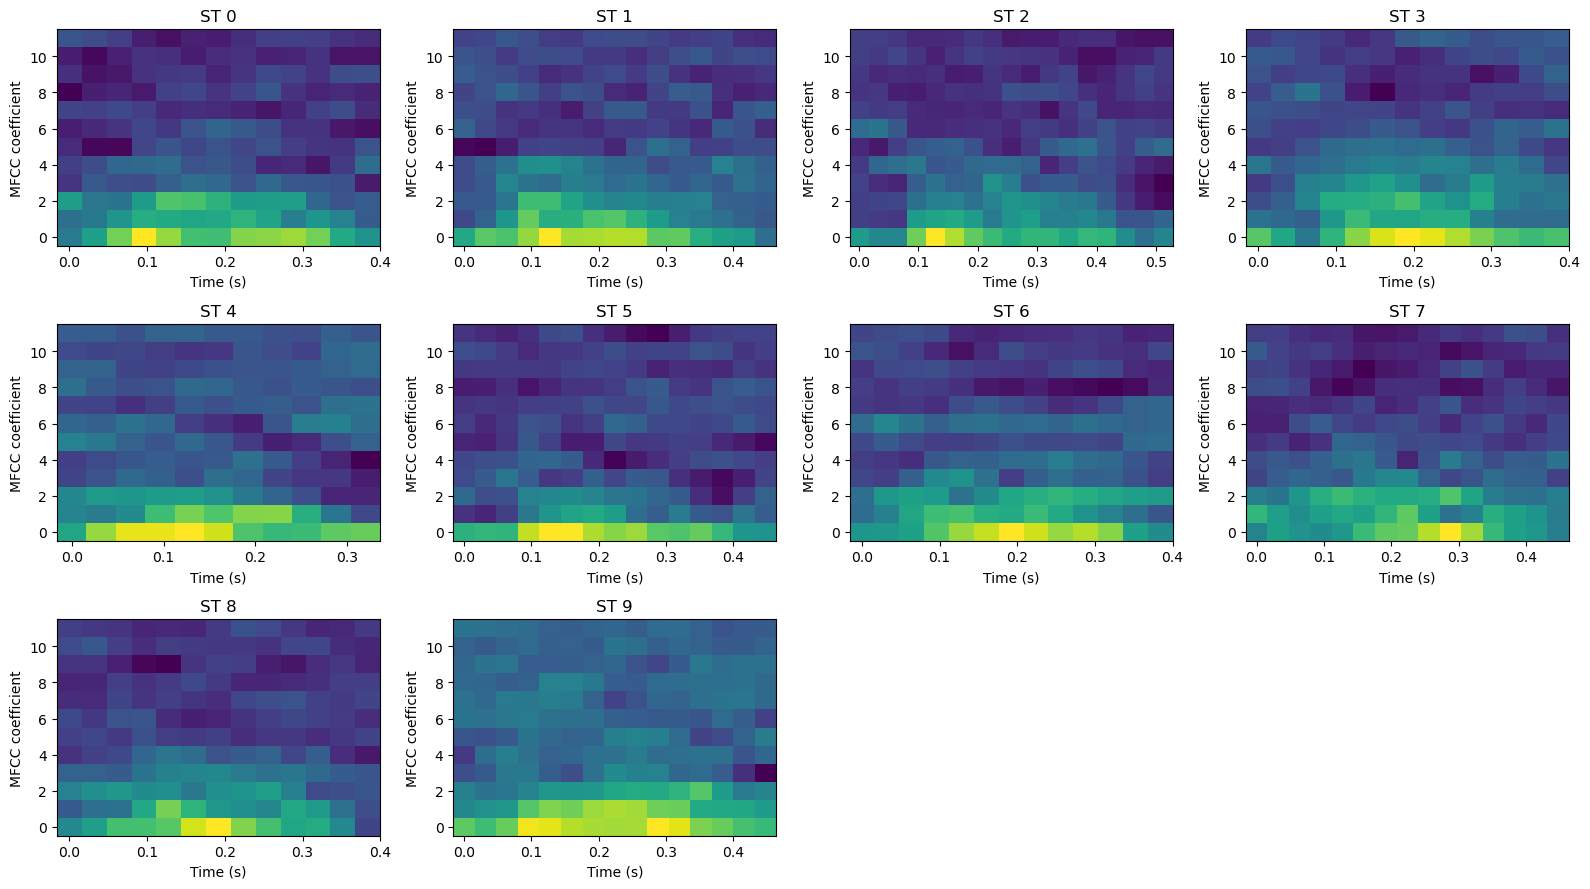

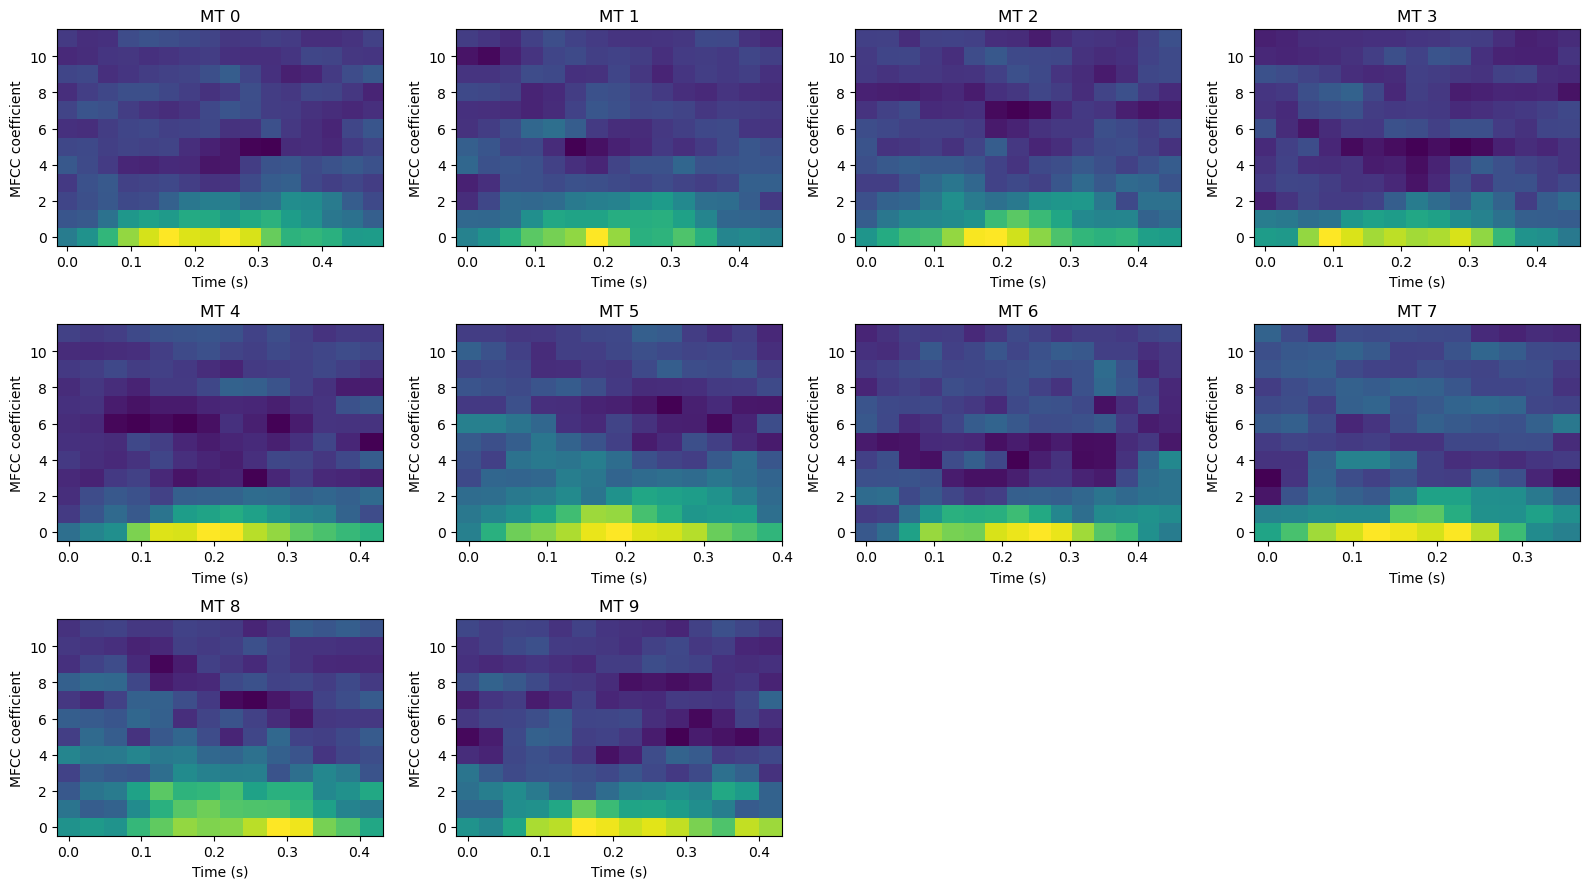

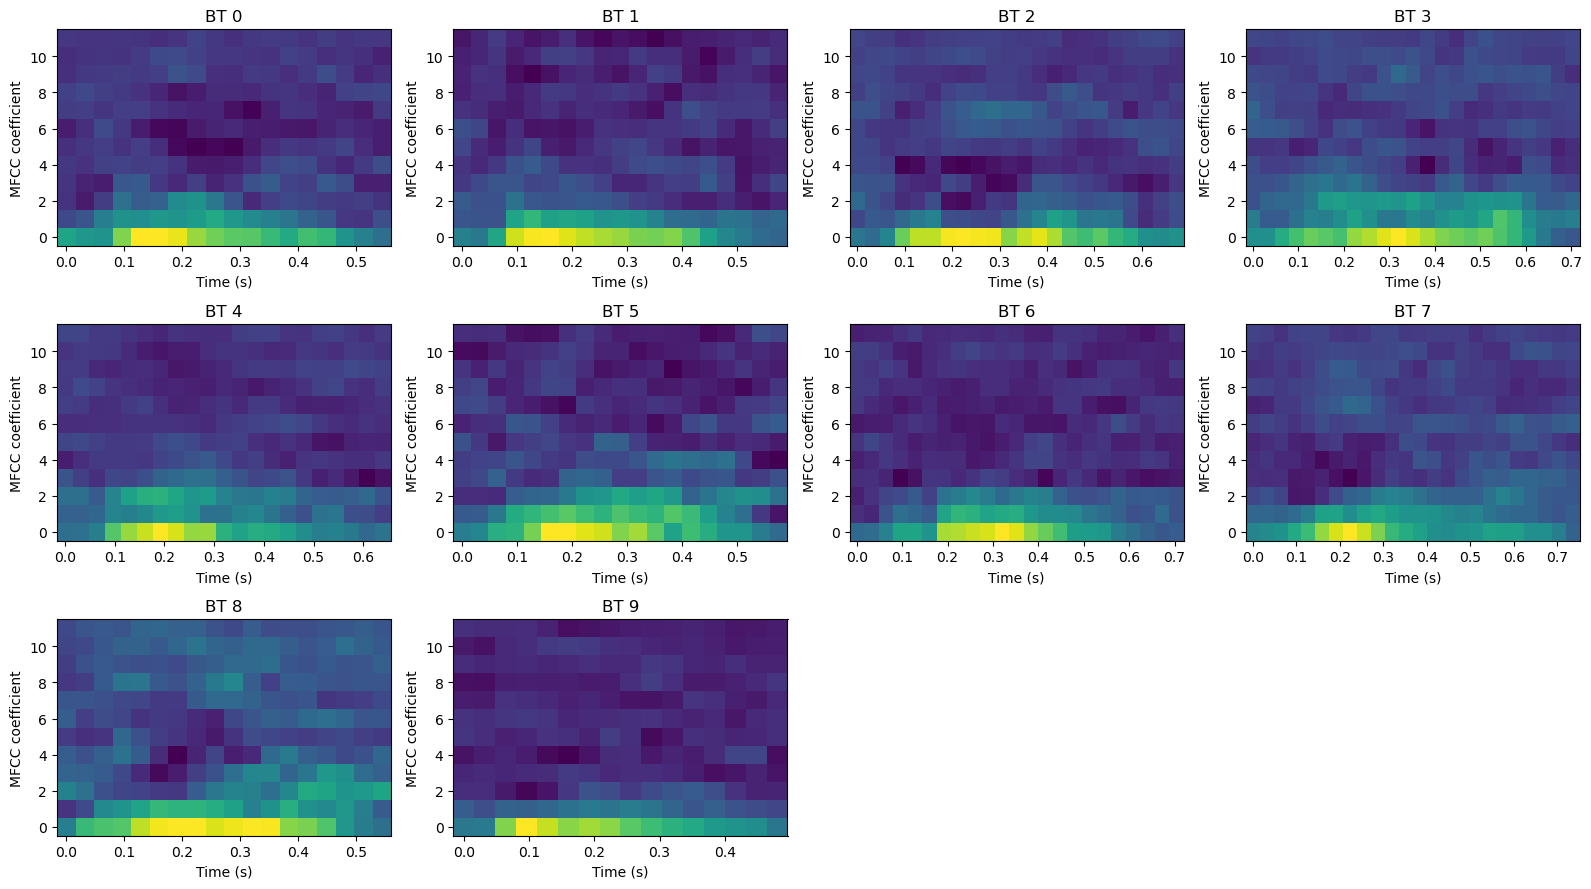

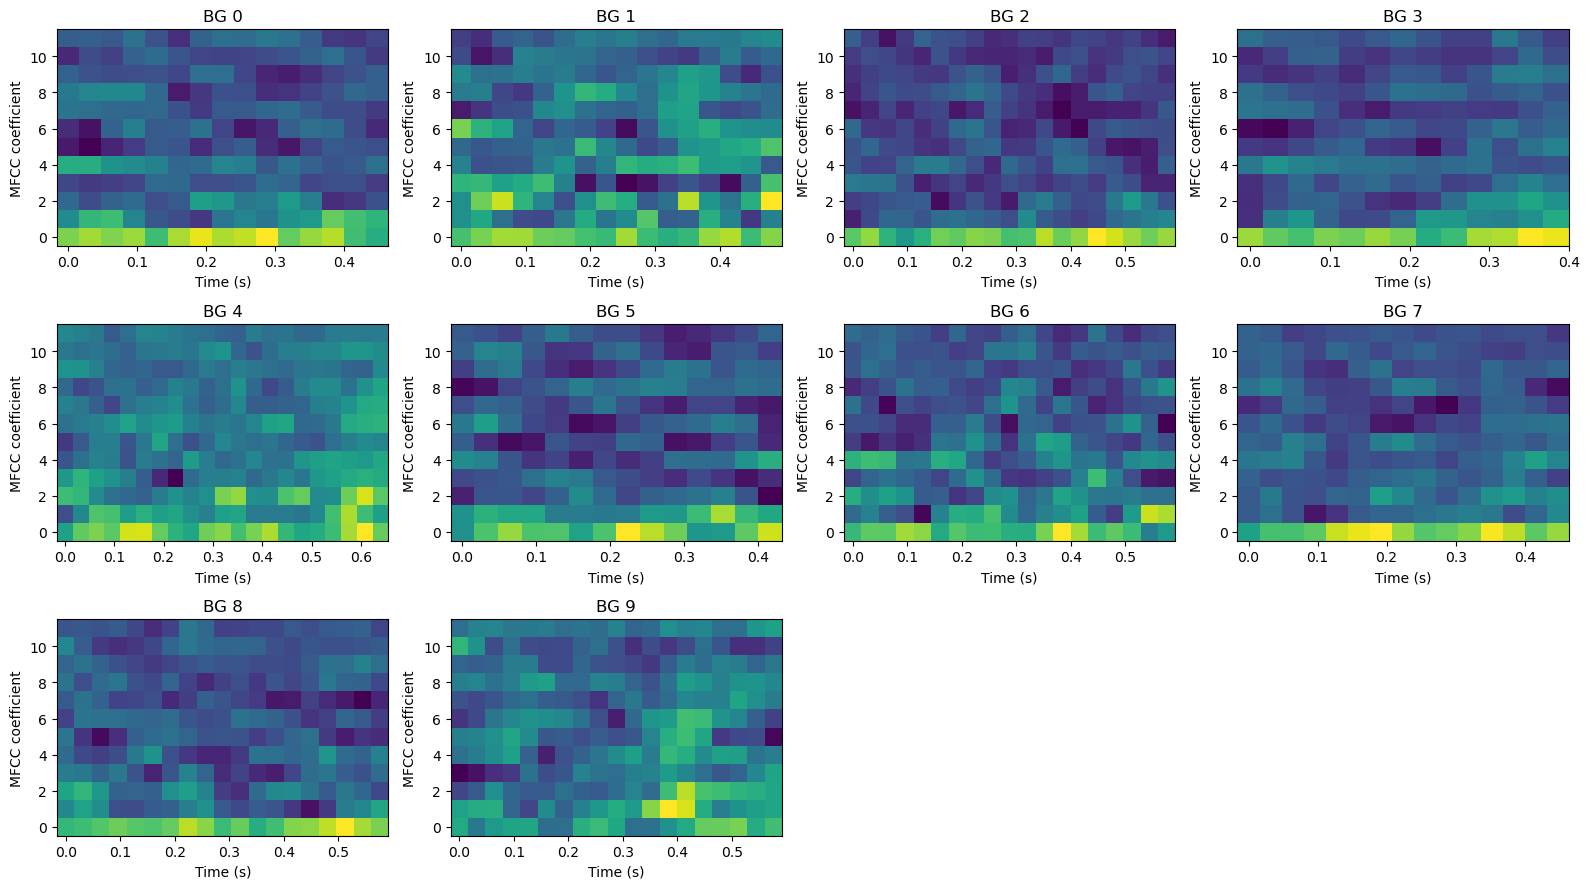

In [3]:
fs_new = 1000

hop_samples = int(fs_new * extractor.params["frame_dur"] * (1 - extractor.params["overlap"]))

plot_mfcc_grid(calib_features_by_type["single_tone"], fs_new, hop_samples, "ST")
plot_mfcc_grid(calib_features_by_type["multi_tone"], fs_new, hop_samples, "MT")
plot_mfcc_grid(calib_features_by_type["burst_tonal"], fs_new, hop_samples, "BT")
plot_mfcc_grid(bg_features, fs_new, hop_samples, "BG")

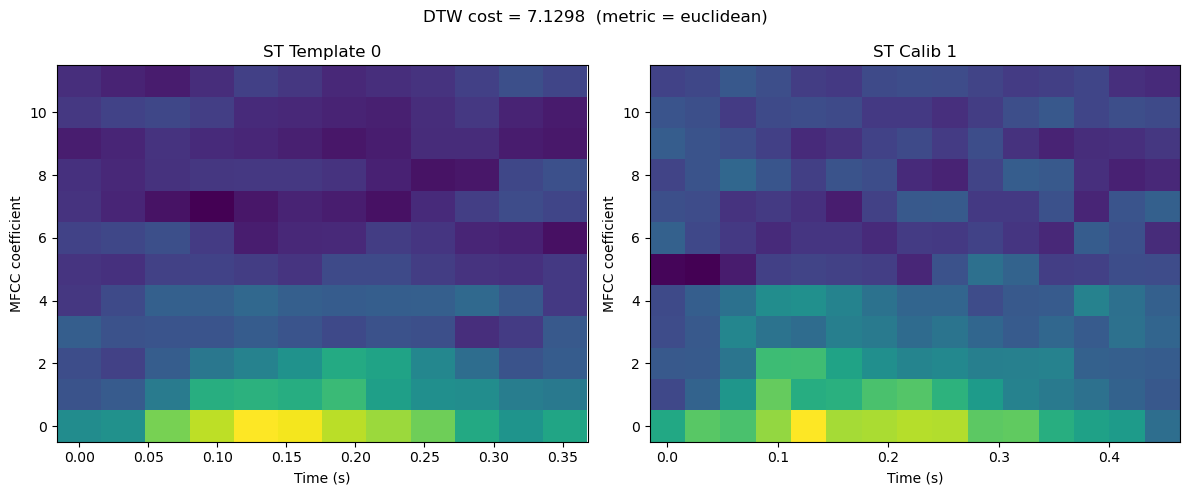

DTW cost: 7.1298


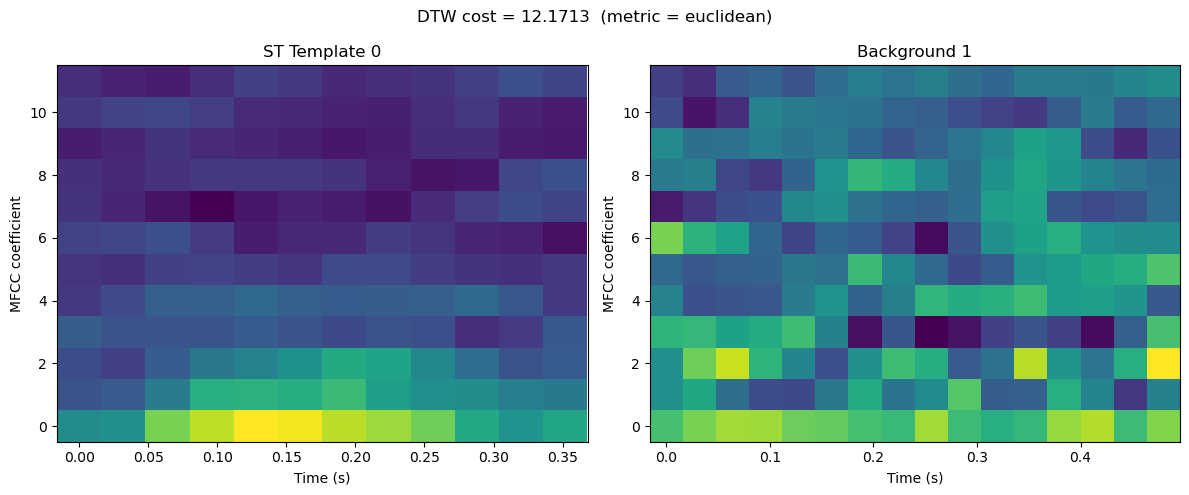

DTW cost vs background: 12.1713


In [4]:
from feature import (
    load_features_from_json,
    make_mfcc_extractor,
    plot_mfcc_grid,
    plot_mfcc_pair,
)

# ... after your existing loop, where calib_features_by_type and bg_features already exist ...

# Example: compare template 0 of single_tone against calibration call 1
template_features = load_features_from_json(
    RESULTS_29 / f"{TEMPLATE_filename_start}_single_tone_templates.json", extractor, n_temps)

cost = plot_mfcc_pair(
    template_features[0], calib_features_by_type["single_tone"][1],
    fs_new, hop_samples, metric=extractor.metric,
    label_a="ST Template 0", label_b="ST Calib 1",
)
print(f"DTW cost: {cost:.4f}")

# Example: template vs. background instead
cost_bg = plot_mfcc_pair(
    template_features[0], bg_features[1],
    fs_new, hop_samples, metric=extractor.metric,
    label_a="ST Template 0", label_b="Background 1",
)
print(f"DTW cost vs background: {cost_bg:.4f}")